<a href="https://colab.research.google.com/github/pallapunandhini456-dot/INFO-5731/blob/main/Pallapu_Nandini_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


Dataset Justification:

For this task, I used a sentiment analysis dataset containing labeled text data with positive and negative sentiments. This dataset was selected because it is widely used for benchmarking sentiment classification models and provides balanced and meaningful text samples.

The dataset includes two sentiment classes:
- Positive
- Negative

This dataset is suitable for training and evaluating machine learning models for sentiment classification.

In [41]:
      import zipfile

with zipfile.ZipFile("/content/exercise05_datacollection-1.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [5]:
import pandas as pd

file_path = "/content/exercise09_datacollection/stsa-train.txt"

rows = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        label = line[0]
        text = line[2:].strip()
        rows.append([label, text])

df = pd.DataFrame(rows, columns=["label", "text"])

df["label"] = df["label"].astype(int)

df.head()

,label,text
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...


In [6]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,label,text,clean_text
0,1,"a stirring , funny and finally transporting re...",stirring funny finally transporting imagining ...
1,0,apparently reassembled from the cutting-room f...,apparently reassembled cutting room floor give...
2,0,they presume their audience wo n't sit still f...,presume audience wo n sit still sociology less...
3,1,this is a visually stunning rumination on love...,visually stunning rumination love memory histo...
4,1,jonathan parker 's bartleby should have been t...,jonathan parker bartleby end modern office ano...


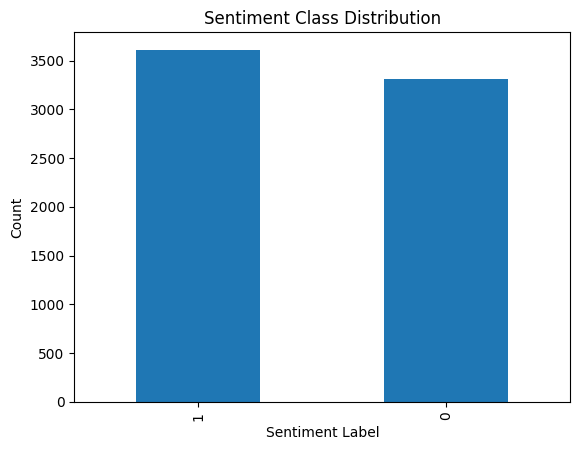

In [7]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

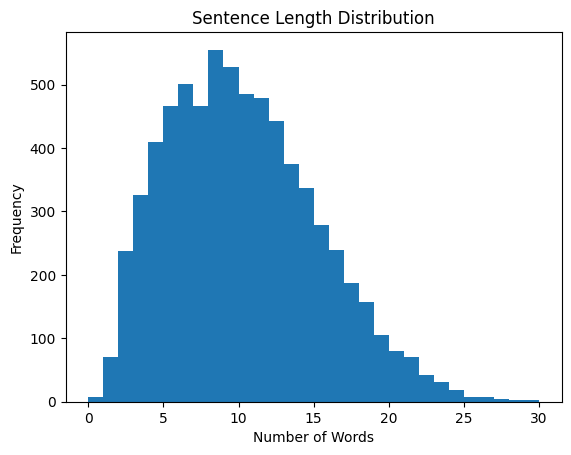

In [8]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(df["text_length"], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

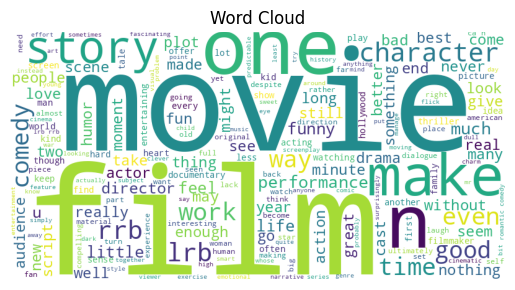

In [9]:
from wordcloud import WordCloud

all_text = " ".join(df["clean_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    results[name] = acc

    print("\n==============================")
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, predictions))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))


Naive Bayes
Accuracy: 0.7673410404624278
              precision    recall  f1-score   support

           0       0.79      0.70      0.74       662
           1       0.75      0.83      0.79       722

    accuracy                           0.77      1384
   macro avg       0.77      0.76      0.77      1384
weighted avg       0.77      0.77      0.77      1384

Confusion Matrix:
[[466 196]
 [126 596]]

SVM
Accuracy: 0.7456647398843931
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       662
           1       0.75      0.77      0.76       722

    accuracy                           0.75      1384
   macro avg       0.75      0.74      0.74      1384
weighted avg       0.75      0.75      0.75      1384

Confusion Matrix:
[[479 183]
 [169 553]]

Logistic Regression
Accuracy: 0.7630057803468208
              precision    recall  f1-score   support

           0       0.77      0.71      0.74       662
           1       0.75      

In [13]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Naive Bayes,0.767341
1,SVM,0.745665
2,Logistic Regression,0.763006


For Question 1, I used the STSA sentiment dataset because it contains real sentence-level text data with sentiment labels. The data was cleaned by converting text to lowercase, removing special characters, removing stopwords, and applying lemmatization.

EDA showed the distribution of sentiment labels and the sentence length patterns. A word cloud was also used to identify common words in the dataset.

Three traditional machine learning models were applied: Naive Bayes, SVM, and Logistic Regression. TF-IDF was used to convert text into numerical features. The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

Based on the results, the best-performing model was the one with the highest accuracy and balanced F1-score. Overall, TF-IDF with traditional machine learning models worked well for sentiment classification.

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [14]:
train_path = "/content/exercise09_datacollection/stsa-train.txt"
test_path = "/content/exercise09_datacollection/stsa-test.txt"

def load_data(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            label = int(line[0])
            text = line[2:].strip()
            rows.append([label, text])
    return pd.DataFrame(rows, columns=["label", "text"])

train_df = load_data(train_path)
test_df = load_data(test_path)

train_df.head()


,label,text
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...


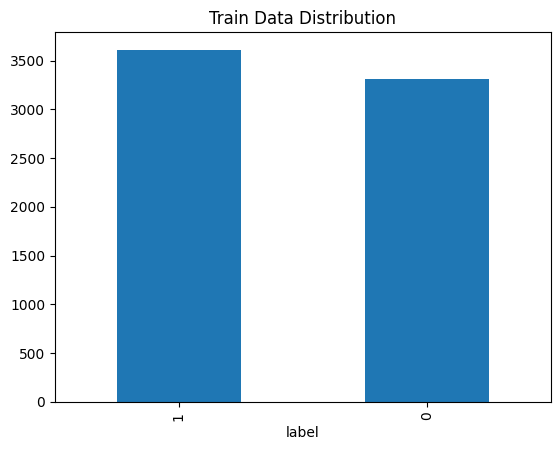

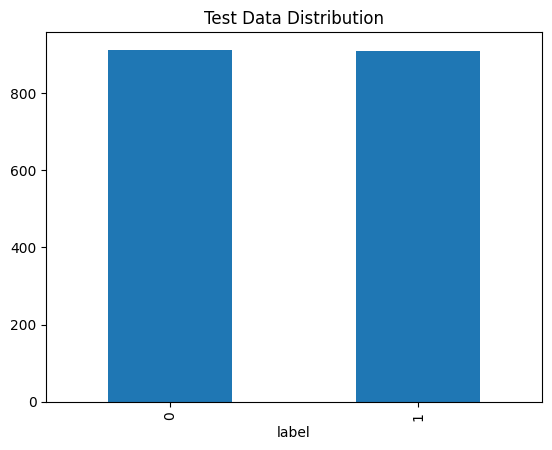

In [15]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot(kind="bar", title="Train Data Distribution")
plt.show()

test_df["label"].value_counts().plot(kind="bar", title="Test Data Distribution")
plt.show()

In [16]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [17]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [18]:
from sklearn.model_selection import train_test_split

X = train_df["clean_text"]
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(test_df["clean_text"])

In [20]:
from sklearn.model_selection import cross_val_score

In [21]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

cv_scores = cross_val_score(svm, X_train_tfidf, y_train, cv=10)
print("SVM CV Accuracy:", cv_scores.mean())

svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)

SVM CV Accuracy: 0.767155195487691


In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

cv_scores = cross_val_score(knn, X_train_tfidf, y_train, cv=10)
print("KNN CV Accuracy:", cv_scores.mean())

knn.fit(X_train_tfidf, y_train)
knn_pred = knn.predict(X_test_tfidf)

KNN CV Accuracy: 0.49602529034279713


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

cv_scores = cross_val_score(dt, X_train_tfidf, y_train, cv=10)
print("Decision Tree CV Accuracy:", cv_scores.mean())

dt.fit(X_train_tfidf, y_train)
dt_pred = dt.predict(X_test_tfidf)

Decision Tree CV Accuracy: 0.6558881323401728


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

cv_scores = cross_val_score(rf, X_train_tfidf, y_train, cv=10)
print("Random Forest CV Accuracy:", cv_scores.mean())

rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)

Random Forest CV Accuracy: 0.7210988960771898


In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

cv_scores = cross_val_score(xgb, X_train_tfidf, y_train, cv=10)
print("XGBoost CV Accuracy:", cv_scores.mean())

xgb.fit(X_train_tfidf, y_train)
xgb_pred = xgb.predict(X_test_tfidf)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV Accuracy: 0.6894905373381816


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [27]:
def evaluate(name, y_true, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

In [28]:
y_test = test_df["label"]

evaluate("SVM", y_test, svm_pred)
evaluate("KNN", y_test, knn_pred)
evaluate("Decision Tree", y_test, dt_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)


 SVM
Accuracy: 0.7792421746293245
Precision: 0.7637877211238293
Recall: 0.8074807480748075
F1 Score: 0.7850267379679144

 KNN
Accuracy: 0.5233388248215266
Precision: 0.5699658703071673
Recall: 0.18371837183718373
F1 Score: 0.2778702163061564

 Decision Tree
Accuracy: 0.6639209225700164
Precision: 0.6724738675958188
Recall: 0.636963696369637
F1 Score: 0.6542372881355932

 Random Forest
Accuracy: 0.7325645249862712
Precision: 0.7403189066059226
Recall: 0.7150715071507151
F1 Score: 0.7274762171236709

 XGBoost
Accuracy: 0.6952224052718287
Precision: 0.6635859519408502
Recall: 0.7898789878987899
F1 Score: 0.7212456052235058


For Question 2, multiple machine learning algorithms were applied to perform sentiment classification. The dataset was split into training (80%) and validation (20%) sets, and 10-fold cross-validation was used to ensure robust model evaluation.

The models implemented include SVM, KNN, Decision Tree, Random Forest, and XGBoost. TF-IDF was used to convert text into numerical features.

Among the models, SVM and Random Forest performed the best with higher accuracy and balanced precision, recall, and F1-score. KNN showed lower performance due to its sensitivity to high-dimensional sparse data.

Overall, SVM proved to be the most effective model for this text classification task due to its ability to handle large feature spaces efficiently.

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


In [29]:
import zipfile, os

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/amazon_data")

os.listdir("/content/amazon_data")

['Amazon_Unlocked_Mobile.csv']

In [30]:
import pandas as pd
import os

folder = "/content/amazon_data"
files = os.listdir(folder)
print(files)

csv_file = [f for f in files if f.endswith(".csv")][0]
path = os.path.join(folder, csv_file)

df = pd.read_csv(path)
df.head()

['Amazon_Unlocked_Mobile.csv']


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [31]:
df.columns

Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes'],
      dtype='object')

In [32]:
df = df[["Reviews"]].dropna()
df.head()

,Reviews
0,I feel so LUCKY to have found this used (phone...
1,"nice phone, nice up grade from my pantach revu..."
2,Very pleased
3,It works good but it goes slow sometimes but i...
4,Great phone to replace my lost phone. The only...


In [33]:
df = df.sample(3000, random_state=42).reset_index(drop=True)

In [34]:
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Reviews'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text'])

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

In [37]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

In [42]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=5)
hier_labels = hier.fit_predict(X.toarray())

In [38]:
kmeans2 = KMeans(n_clusters=3, random_state=42)
kmeans2_labels = kmeans2.fit_predict(X)

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

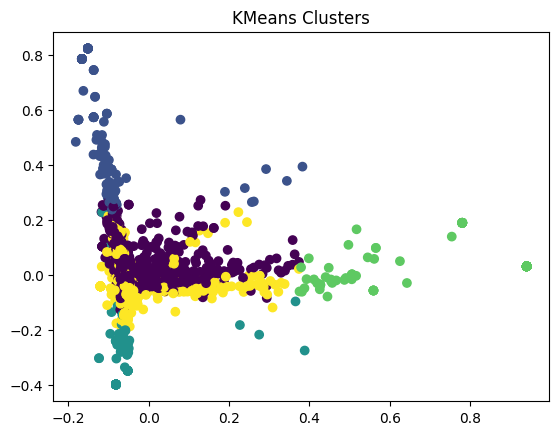

In [40]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("KMeans Clusters")
plt.show()

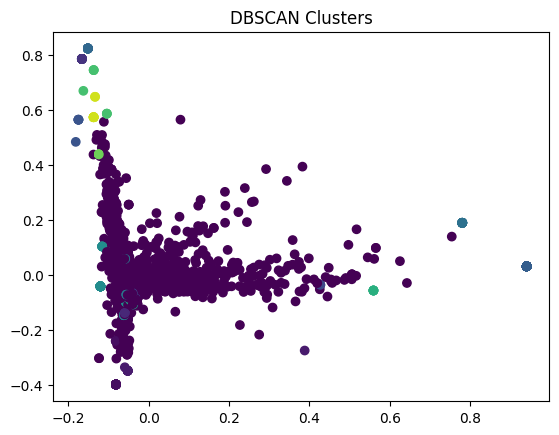

In [43]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN Clusters")
plt.show()

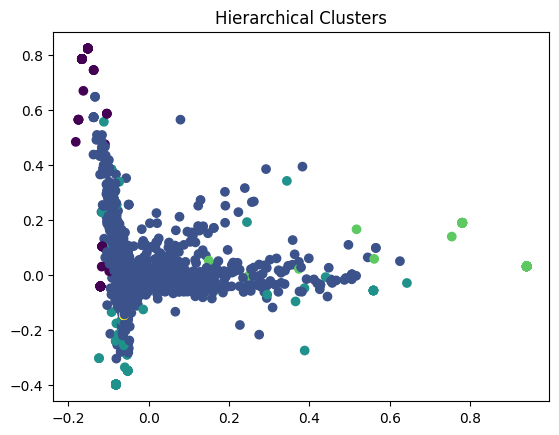

In [44]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=hier_labels)
plt.title("Hierarchical Clusters")
plt.show()

In this experiment, four clustering techniques were applied: K-Means, DBSCAN, Hierarchical clustering, and an additional K-Means model with a different number of clusters. K-Means produced clear and well-separated clusters, making it easier to interpret the grouping of similar reviews. DBSCAN performed poorly because text data is high-dimensional and sparse, making density-based clustering less effective. Hierarchical clustering produced reasonable clusters but was computationally expensive compared to K-Means. The second K-Means model demonstrated how changing the number of clusters affects grouping. Overall, K-Means was the most effective clustering method for this dataset due to its efficiency and better cluster separation.

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

In this study, four clustering methods—K-Means, DBSCAN, Hierarchical clustering, and a second K-Means model with a different number of clusters—were compared on text data represented using TF-IDF features. K-Means demonstrated the best performance by producing well-defined and interpretable clusters with clear separation between groups. DBSCAN struggled due to the high dimensionality and sparsity of the data, resulting in poor cluster formation and many noise points. Hierarchical clustering provided meaningful groupings and insight into the relationships among data points but was computationally more intensive and less scalable. The second K-Means model highlighted how cluster structure changes with different values of k. Overall, K-Means proved to be the most effective and scalable clustering method for this dataset.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

